In [50]:
import json
import pandas as pd
import numpy as np
import re
from datasets import load_dataset
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from itertools import combinations

In [2]:
DATASET_PATH=r"F:\SEM-7\Capstone\DatasetBuilder\DatasetBuilderBlue\outputs\train_blue.jsonl"
dataset=load_dataset("json",data_files=DATASET_PATH,split="train")

df = dataset.to_pandas()
print(f"Total Samples : {len(df)}")
display(df.head())


Total Samples : 551


,scenario_id,example_id,messages
0,scenario_001,B1,"[{'role': 'system', 'content': 'You are a Blue..."
1,scenario_001,B2,"[{'role': 'system', 'content': 'You are a Blue..."
2,scenario_001,B3,"[{'role': 'system', 'content': 'You are a Blue..."
3,scenario_002,B1,"[{'role': 'system', 'content': 'You are a Blue..."
4,scenario_002,B2,"[{'role': 'system', 'content': 'You are a Blue..."


In [3]:
print(f"Number of Samples          : {len(df)}")
print(f"Number of Columns          : {len(df.columns)}")
print(f"Number of Features         : {df.shape[1]}")

print("\nColumn Names")
print(df.columns)
print("\nData Types")
display(df.dtypes)


Number of Samples          : 551
Number of Columns          : 3
Number of Features         : 3

Column Names
Index(['scenario_id', 'example_id', 'messages'], dtype='object')

Data Types


scenario_id    object
example_id     object
messages       object
dtype: object

In [4]:
missing=pd.DataFrame({"Missing Count":df.isnull().sum(),
                      "Missing Percentage":(df.isnull().sum() / len(df) * 100).round(2)})
display(missing)
total_missing = missing["Missing Count"].sum()
print()
print(f"Total Missing Values : {total_missing}")

,Missing Count,Missing Percentage
scenario_id,0,0.0
example_id,0,0.0
messages,0,0.0



Total Missing Values : 0


In [7]:
serialized_rows=df.apply(lambda row: json.dumps(row.to_dict(), sort_keys=True, default=str),axis=1)

duplicate_rows=serialized_rows.duplicated().sum()
print(f"Total Samples     : {len(df)}")
print(f"Duplicate Samples : {duplicate_rows}")
print(f"Unique Samples    : {len(df) - duplicate_rows}")
print(f"Duplicate Rate    : {(duplicate_rows / len(df)) * 100:.2f}%")

Total Samples     : 551
Duplicate Samples : 0
Unique Samples    : 551
Duplicate Rate    : 0.00%


In [ ]:
# Extract Conversation Components

def extract_message(messages, role):
    for message in messages:
        if message["role"] == role:
            return message["content"]
    return ""

df["system_prompt"] = df["messages"].apply(lambda x: extract_message(x, "system"))
df["user_prompt"] = df["messages"].apply(lambda x: extract_message(x, "user"))
df["assistant_response"] = df["messages"].apply(lambda x: extract_message(x, "assistant"))

display(df[["system_prompt","user_prompt","assistant_response"]].head())

,system_prompt,user_prompt,assistant_response
0,You are a Blue Team cybersecurity analyst spec...,Perform a comprehensive Blue Team review of th...,Defense: rotate_jwt_secret\n\nReasoning: The a...
1,You are a Blue Team cybersecurity analyst spec...,Analyze the following enterprise codebase as a...,Defense: rotate_jwt_secret\n\nReasoning: JWT f...
2,You are a Blue Team cybersecurity analyst spec...,Analyze the following enterprise codebase as a...,Defense: rotate_jwt_secret\n\nReasoning: The /...
3,You are a Blue Team cybersecurity analyst spec...,Perform a comprehensive Blue Team review of th...,Defense: ownership_validation\n\nReasoning:\n1...
4,You are a Blue Team cybersecurity analyst spec...,You are conducting an architectural security a...,Defense: ownership_validation\n\nReasoning:\n1...


# Conversation Statistics

In [ ]:
df["system_chars"]   =df["system_prompt"].str.len()
df["user_chars"]     =df["user_prompt"].str.len()
df["assistant_chars"]=df["assistant_response"].str.len()

stats=pd.DataFrame({
    "Field" : ["System Prompt","User Prompt","Assistant Response"],
    "Mean"  : [df["system_chars"].mean(),df["user_chars"].mean(),df["assistant_chars"].mean()],
    "Median": [df["system_chars"].median(),df["user_chars"].median(),df["assistant_chars"].median()],
    "Min"   : [df["system_chars"].min(),df["user_chars"].min(),df["assistant_chars"].min()],
    "Max"   : [df["system_chars"].max(),df["user_chars"].max(),df["assistant_chars"].max()],
    "Std"   : [df["system_chars"].std(),df["user_chars"].std(),df["assistant_chars"].std()]})

display(stats.round(2))

,Field,Mean,Median,Min,Max,Std
0,System Prompt,1402.00,1402.0,1402,1402,0.00
1,User Prompt,34969.14,33082.0,3446,95861,17748.40
2,Assistant Response,2052.15,2047.0,168,4108,874.22


# Character Length Distribution

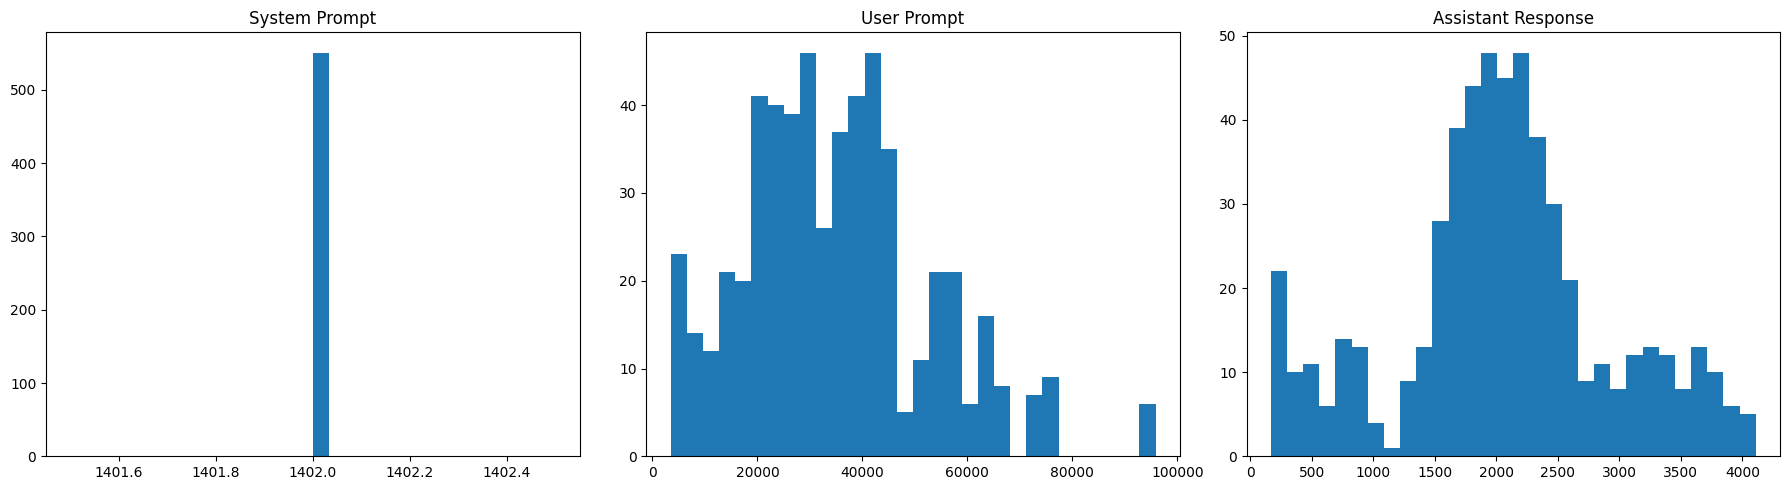

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

ax[0].hist(df["system_chars"], bins=30)
ax[0].set_title("System Prompt")
ax[1].hist(df["user_chars"], bins=30)
ax[1].set_title("User Prompt")
ax[2].hist(df["assistant_chars"], bins=30)
ax[2].set_title("Assistant Response")

plt.tight_layout()
plt.show()

# Prompt Token Statistics

In [ ]:
MODELS = {"Meta-Llama-3.1-8B-Instruct": "unsloth/Meta-Llama-3.1-8B-Instruct",
          "Qwen2.5-7B-Instruct": "unsloth/Qwen2.5-7B-Instruct",
          "Qwen3-8B": "unsloth/Qwen3-8B"}

results=[]
tokenizers={}

for model_name, model_path in MODELS.items():
    print(f"Loading Tokenizer: {model_name}")
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_path,trust_remote_code=True)
        tokenizers[model_name] = tokenizer
        prompt_tokens = []

        for _, row in df.iterrows():
            prompt = (row["system_prompt"] + "\n" + row["user_prompt"])
            token_count = len(tokenizer(prompt,add_special_tokens=False)["input_ids"])
            prompt_tokens.append(token_count)

        token_series = pd.Series(prompt_tokens)

        results.append({
            "Tokenizer": model_name,
            "Mean"    : round(token_series.mean(), 2),
            "Median"  : round(token_series.median(), 2),
            "Minimum" : int(token_series.min()),
            "Maximum" : int(token_series.max()),
            "Std Dev" : round(token_series.std(), 2),
            "Variance": round(token_series.var(), 2),
            "90%": round(token_series.quantile(0.90), 2),
            "95%": round(token_series.quantile(0.95), 2),
            "99%": round(token_series.quantile(0.99), 2),})

        print("Success")

    except Exception as e:
        print(f"Failed to load {model_name}")
        print(e)

comparison = pd.DataFrame(results)

print("\n")
print("=" * 120)
print("PROMPT TOKENIZER COMPARISON")
print("=" * 120)

display(comparison)

print("\nLoaded Tokenizers:")
print(list(tokenizers.keys()))

Loading Tokenizer: Meta-Llama-3.1-8B-Instruct
✓ Success
Loading Tokenizer: Qwen2.5-7B-Instruct
✓ Success
Loading Tokenizer: Qwen3-8B
✓ Success


PROMPT TOKENIZER COMPARISON


,Tokenizer,Mean,Median,Minimum,Maximum,Std Dev,Variance,90%,95%,99%
0,Meta-Llama-3.1-8B-Instruct,6631.72,6231.0,916,18786,3359.37,11285348.16,11527.0,12904.5,17386.5
1,Qwen2.5-7B-Instruct,6651.55,6237.0,922,18892,3369.82,11355654.80,11564.0,12947.5,17459.0
2,Qwen3-8B,6651.55,6237.0,922,18892,3369.82,11355654.80,11564.0,12947.5,17459.0



Loaded Tokenizers:
['Meta-Llama-3.1-8B-Instruct', 'Qwen2.5-7B-Instruct', 'Qwen3-8B']


# Assistant Response Token Statistics Comparison

In [ ]:
results=[]

for model_name, tokenizer in tokenizers.items():
    print(f"Using Tokenizer: {model_name}")

    assistant_tokens=[]

    for text in df["assistant_response"]:
        token_count = len(tokenizer(text,add_special_tokens=False)["input_ids"])
        assistant_tokens.append(token_count)

    token_series=pd.Series(assistant_tokens)

    results.append({
        "Tokenizer": model_name,
        "Mean"    : round(token_series.mean(),2),
        "Median"  : round(token_series.median(),2),
        "Minimum" : int(token_series.min()),
        "Maximum" : int(token_series.max()),
        "Std Dev" : round(token_series.std(),2),
        "Variance": round(token_series.var(),2),
        "90%": round(token_series.quantile(0.90),2),
        "95%": round(token_series.quantile(0.95),2),
        "99%": round(token_series.quantile(0.99),2)})

comparison=pd.DataFrame(results)

print("\n")
print("=" * 120)
print("ASSISTANT RESPONSE TOKENIZER COMPARISON")
print("=" * 120)

display(comparison)

Using Tokenizer: Meta-Llama-3.1-8B-Instruct
Using Tokenizer: Qwen2.5-7B-Instruct
Using Tokenizer: Qwen3-8B


ASSISTANT RESPONSE TOKENIZER COMPARISON


,Tokenizer,Mean,Median,Minimum,Maximum,Std Dev,Variance,90%,95%,99%
0,Meta-Llama-3.1-8B-Instruct,336.94,315.0,25,772,159.31,25380.35,593.0,663.0,708.0
1,Qwen2.5-7B-Instruct,337.56,316.0,25,772,159.51,25442.79,593.0,663.0,708.0
2,Qwen3-8B,337.56,316.0,25,772,159.51,25442.79,593.0,663.0,708.0


# Training Sequence Token Statistics Comparison

In [ ]:
results=[]

for model_name,tokenizer in tokenizers.items():

    print(f"Using Tokenizer: {model_name}")
    training_tokens = []

    for messages in df["messages"]:
        formatted_text = tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=False)
        token_count = len(tokenizer(formatted_text,add_special_tokens=False)["input_ids"])
        training_tokens.append(token_count)

    token_series=pd.Series(training_tokens)

    results.append({
        "Tokenizer": model_name,
        "Mean"    : round(token_series.mean(),2),
        "Median"  : round(token_series.median(),2),
        "Minimum" : int(token_series.min()),
        "Maximum" : int(token_series.max()),
        "Std Dev" : round(token_series.std(),2),
        "Variance": round(token_series.var(),2),
        "90%": round(token_series.quantile(0.90),2),
        "95%": round(token_series.quantile(0.95),2),
        "99%": round(token_series.quantile(0.99),2)})

comparison=pd.DataFrame(results)

print("\n")
print("=" * 120)
print("TRAINING SEQUENCE TOKENIZER COMPARISON")
print("=" * 120)

display(comparison)

Using Tokenizer: Meta-Llama-3.1-8B-Instruct
Using Tokenizer: Qwen2.5-7B-Instruct
Using Tokenizer: Qwen3-8B


TRAINING SEQUENCE TOKENIZER COMPARISON


,Tokenizer,Mean,Median,Minimum,Maximum,Std Dev,Variance,90%,95%,99%
0,Meta-Llama-3.1-8B-Instruct,7004.66,6555.0,999,19253,3423.67,11721530.34,11986.0,13298.5,17792.5
1,Qwen2.5-7B-Instruct,7004.11,6552.0,984,19338,3433.78,11790850.97,12002.0,13320.5,17844.0
2,Qwen3-8B,7008.11,6556.0,988,19342,3433.78,11790850.97,12006.0,13324.5,17848.0


# Token Length Distribution

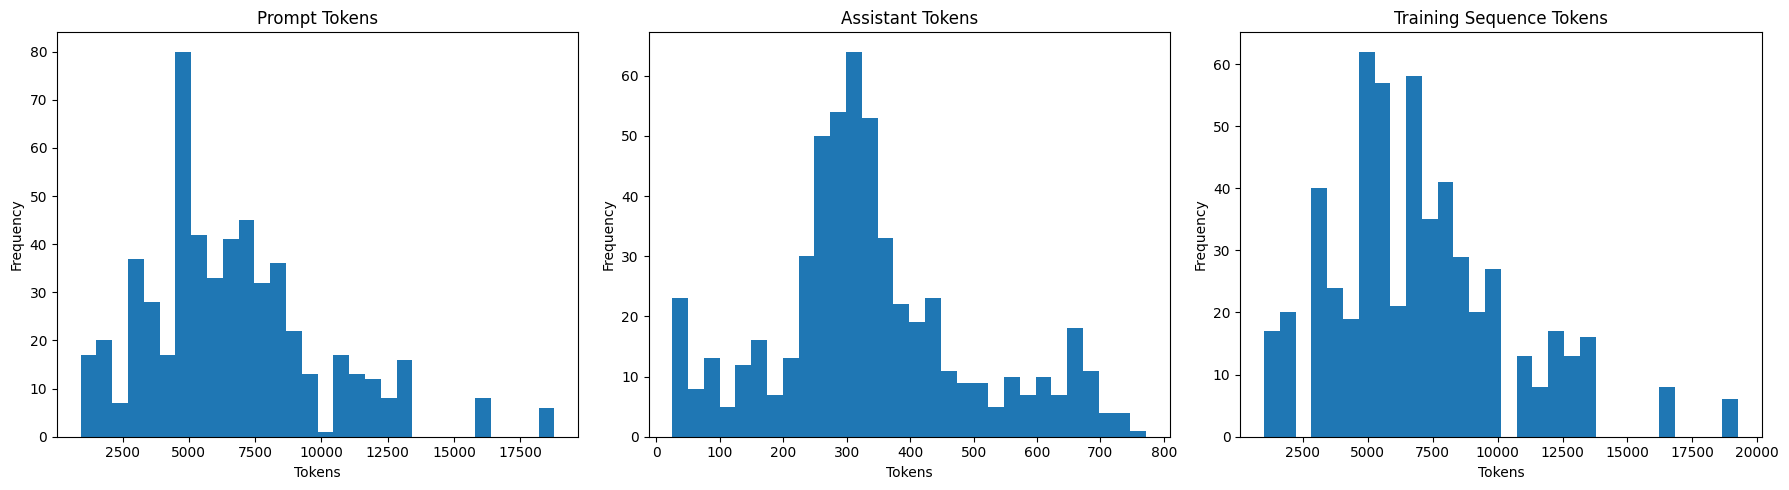

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

ax[0].hist(df["prompt_tokens"], bins=30)
ax[0].set_title("Prompt Tokens")
ax[0].set_xlabel("Tokens")
ax[0].set_ylabel("Frequency")

ax[1].hist(df["assistant_tokens"], bins=30)
ax[1].set_title("Assistant Tokens")
ax[1].set_xlabel("Tokens")
ax[1].set_ylabel("Frequency")

ax[2].hist(df["training_tokens"], bins=30)
ax[2].set_title("Training Sequence Tokens")
ax[2].set_xlabel("Tokens")
ax[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Token Length Boxplots

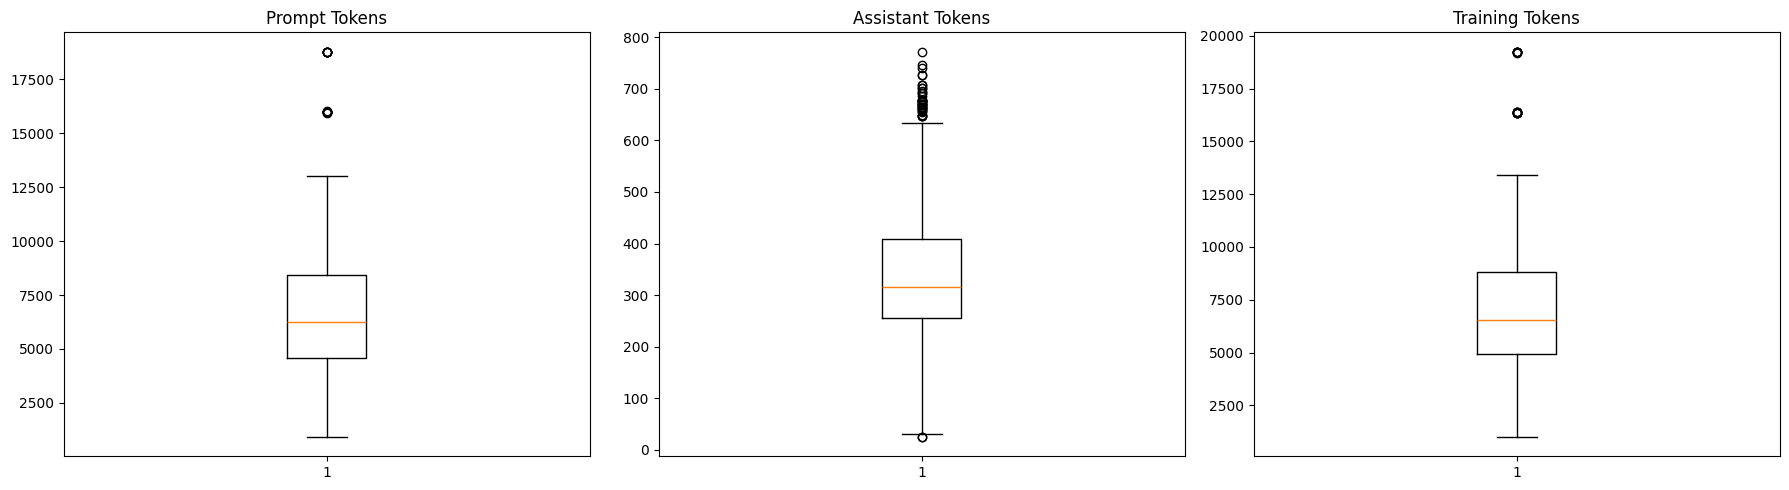

In [37]:
fig, ax = plt.subplots(1,3,figsize=(18,5))

ax[0].boxplot(df["prompt_tokens"])
ax[0].set_title("Prompt Tokens")

ax[1].boxplot(df["assistant_tokens"])
ax[1].set_title("Assistant Tokens")

ax[2].boxplot(df["training_tokens"])
ax[2].set_title("Training Tokens")

plt.tight_layout()
plt.show()

# Outliers using IQR

In [ ]:
Q1=df["training_tokens"].quantile(0.25)
Q3=df["training_tokens"].quantile(0.75)
IQR=Q3 - Q1
upper=Q3 + 1.5 * IQR

outliers = df[df["training_tokens"]>upper]

print(f"Upper Bound : {upper:.2f}")
print(f"Outliers    : {len(outliers)}")
display(outliers[["scenario_id","training_tokens"]])

Upper Bound : 14711.00
Outliers    : 14


,scenario_id,training_tokens
256,scenario_055,19230
257,scenario_055,19185
258,scenario_055,19224
259,scenario_055,19231
260,scenario_055,19245
261,scenario_055,19253
503,scenario_095,16393
504,scenario_095,16339
505,scenario_095,16373
506,scenario_095,16334


# Context Window Coverage

In [ ]:
context_windows = [1024,2048,4096,6144,8192,12248]
coverage=[]

for window in context_windows:

    covered=(df["training_tokens"] <= window).sum()
    coverage.append({"Context Window": window,
                     "Samples Covered": covered,
                     "Coverage (%)": round(covered / len(df) * 100,2)})

coverage=pd.DataFrame(coverage)
display(coverage)

,Context Window,Samples Covered,Coverage (%)
0,1024,2,0.36
1,2048,27,4.90
2,4096,104,18.87
3,6144,243,44.10
4,8192,390,70.78
5,12248,501,90.93


# Cumulative Distribution Function

In [57]:
plt.figure(figsize=(10, 6))

token_columns = {
    "Meta-Llama": "llama_training_tokens",
    "Qwen2.5": "qwen25_training_tokens",
    "Qwen3": "qwen3_training_tokens"
}

for model_name, column in token_columns.items():

    sorted_tokens = np.sort(df[column])
    cdf = np.arange(1, len(sorted_tokens) + 1) / len(sorted_tokens)

    plt.plot(
        sorted_tokens,
        cdf,
        linewidth=2,
        label=model_name
    )

plt.xlabel("Training Sequence Tokens")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Training Sequence Lengths")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

KeyError: 'llama_training_tokens'

<Figure size 1000x600 with 0 Axes>

# Largest Training Samples

In [40]:
largest = df.nlargest(40,"training_tokens")
[
    [
        "scenario_id",
        "training_tokens",
        "prompt_tokens",
        "assistant_tokens"
    ]
]

display(largest)

,scenario_id,example_id,messages,system_prompt,user_prompt,assistant_response,system_chars,user_chars,assistant_chars,prompt_tokens,assistant_tokens,training_tokens,response_prompt_ratio,chars_per_token,valid_format
261,scenario_055,B6,"[{'role': 'system', 'content': 'You are a Blue...",You are a Blue Team cybersecurity analyst spec...,Analyze the following enterprise codebase as a...,Defense: Preserve End-to-End Template Provenan...,1402,95718,2728,18769,448,19253,0.023869,6.089286,False
260,scenario_055,B5,"[{'role': 'system', 'content': 'You are a Blue...",You are a Blue Team cybersecurity analyst spec...,Perform a comprehensive Blue Team review of th...,Defense: Preserve Canonical Template Provenanc...,1402,95773,2805,18769,440,19245,0.023443,6.375000,False
259,scenario_055,B4,"[{'role': 'system', 'content': 'You are a Blue...",You are a Blue Team cybersecurity analyst spec...,Analyze the following enterprise codebase as a...,Defense: Maintain Canonical Template Provenanc...,1402,95714,2631,18760,435,19231,0.023188,6.048276,False
256,scenario_055,B1,"[{'role': 'system', 'content': 'You are a Blue...",You are a Blue Team cybersecurity analyst spec...,You are conducting an architectural security a...,Defense: Preserve Template Provenance Througho...,1402,95861,2575,18786,408,19230,0.021718,6.311275,False
258,scenario_055,B3,"[{'role': 'system', 'content': 'You are a Blue...",You are a Blue Team cybersecurity analyst spec...,You are conducting an architectural security a...,Defense: Preserve Canonical Template Identity ...,1402,95816,2539,18780,408,19224,0.021725,6.223039,False
257,scenario_055,B2,"[{'role': 'system', 'content': 'You are a Blue...",You are a Blue Team cybersecurity analyst spec...,Perform a comprehensive Blue Team review of th...,Defense: Preserve Canonical Template Provenanc...,1402,95782,2303,18776,373,19185,0.019866,6.174263,False
507,scenario_095,B5,"[{'role': 'system', 'content': 'You are a Blue...",You are a Blue Team cybersecurity analyst spec...,You are conducting an architectural security a...,Defense: preserve_complete_authorization_ident...,1402,77245,2402,16002,362,16400,0.022622,6.635359,False
508,scenario_095,B6,"[{'role': 'system', 'content': 'You are a Blue...",You are a Blue Team cybersecurity analyst spec...,You are conducting an architectural security a...,Defense: preserve_authorization_continuity_acr...,1402,77193,2416,15989,373,16398,0.023329,6.477212,False
503,scenario_095,B1,"[{'role': 'system', 'content': 'You are a Blue...",You are a Blue Team cybersecurity analyst spec...,You are conducting an architectural security a...,Defense: preserve_canonical_authorization_grap...,1402,77302,2226,16013,344,16393,0.021483,6.470930,False
505,scenario_095,B3,"[{'role': 'system', 'content': 'You are a Blue...",You are a Blue Team cybersecurity analyst spec...,Analyze the following enterprise codebase as a...,Defense: validate_complete_authorization_graph...,1402,77172,2156,16001,336,16373,0.020999,6.416667,False


# Prompt vs Assistant Correlation

Pearson Correlation : 0.3838


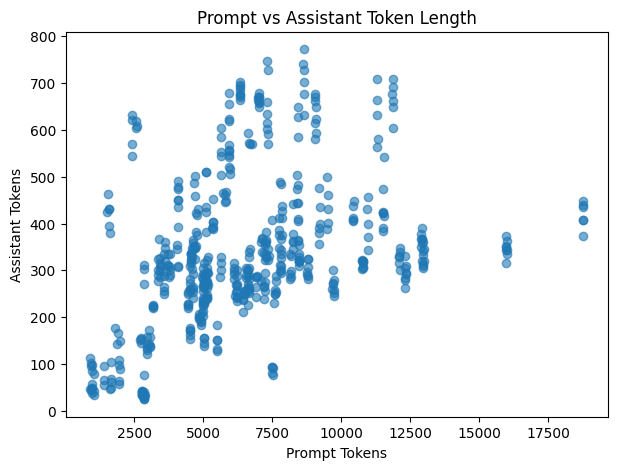

In [ ]:
corr=df["prompt_tokens"].corr(df["assistant_tokens"])
print(f"Pearson Correlation : {corr:.4f}")

plt.figure(figsize=(7,5))
plt.scatter(df["prompt_tokens"],df["assistant_tokens"],alpha=0.6)
plt.xlabel("Prompt Tokens")
plt.ylabel("Assistant Tokens")
plt.title("Prompt vs Assistant Token Length")
plt.show()

# Response-to-Prompt Ratio

count    551.000
mean       0.059
std        0.039
min        0.009
25%        0.038
50%        0.049
75%        0.075
max        0.295
Name: response_prompt_ratio, dtype: float64


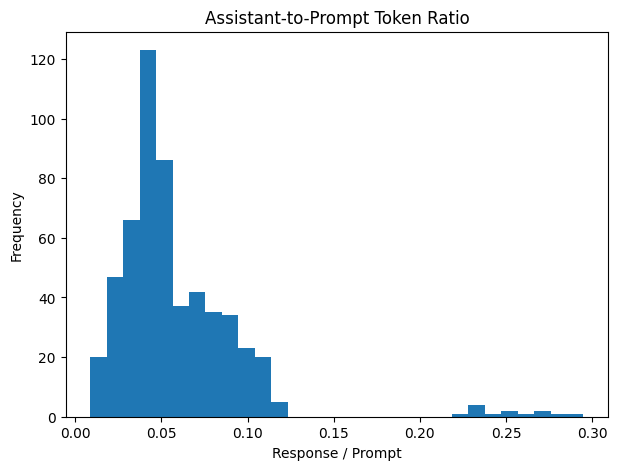

In [ ]:

df["response_prompt_ratio"] = (df["assistant_tokens"] / df["prompt_tokens"])
print(df["response_prompt_ratio"].describe().round(3))

plt.figure(figsize=(7,5))
plt.hist(df["response_prompt_ratio"], bins=30)
plt.title("Assistant-to-Prompt Token Ratio")
plt.xlabel("Response / Prompt")
plt.ylabel("Frequency")
plt.show()

count    551.00
mean       6.19
std        0.60
min        4.65
25%        5.64
50%        6.29
75%        6.64
max        7.77
Name: chars_per_token, dtype: float64


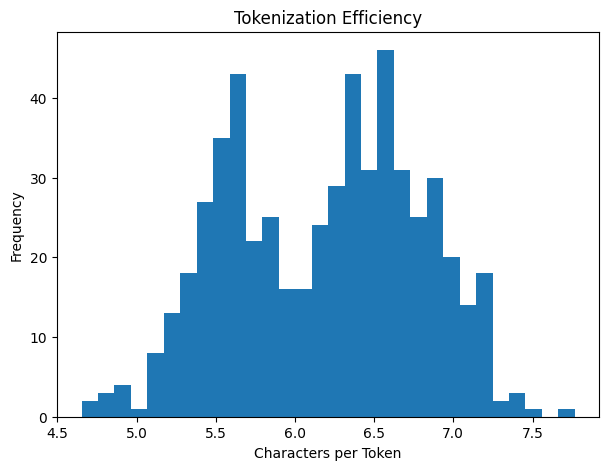

In [ ]:
df["chars_per_token"] = (df["assistant_chars"] /df["assistant_tokens"])

print(df["chars_per_token"].describe().round(2))

plt.figure(figsize=(7,5))
plt.hist(df["chars_per_token"], bins=30)
plt.xlabel("Characters per Token")
plt.ylabel("Frequency")
plt.title("Tokenization Efficiency")
plt.show()

# Assistant response format compliance

In [ ]:
label_re = re.compile(r'^Defense:\s*(.+?)\n\nReasoning:\s*(.*)$',re.DOTALL)

def check_format(row):
    m=label_re.match(row["assistant_response"].strip())
    return m is not None

df["format_compliant"]=df.apply(check_format,axis=1)

non_compliant=df[~df["format_compliant"]]
print(f"Format non-compliant: {len(non_compliant)} / {len(df)}")

display(non_compliant[["scenario_id", "example_id", "assistant_response"]].assign(preview=lambda d: d["assistant_response"].str.slice(0, 200))
        [["scenario_id", "example_id", "preview"]])

Format non-compliant: 0 / 551


,scenario_id,example_id,preview


# Check for Leakage of Reserved Metadata Keys

In [55]:
reserved_keys=["valid_attack","valid_attacks","valid_defense","valid_defenses","optimal_attack","optimal_attacks","optimal_defense","optimal_defenses","metadata.json"]

def scan_leakage(messages):
    if messages is None:
        return []
    # Convert the entire conversation to a string
    # default=str prevents JSON serialization errors
    full_text = json.dumps(messages, default=str)

    # Return all reserved keys found in the conversation
    return [key for key in reserved_keys if key in full_text]


df["leaked_keys"]=df["messages"].apply(scan_leakage)

# Keep only rows where at least one key was found
leaks = df[df["leaked_keys"].apply(len)>0]

print("RESERVED KEY LEAKAGE CHECK")
print(f"Rows with reserved-key leakage: {len(leaks)}/{len(df)}")

if len(leaks) > 0:
    display(leaks[["scenario_id","example_id","leaked_keys"]])
else:
    print("No reserved metadata leakage detected.")

RESERVED KEY LEAKAGE CHECK
Rows with reserved-key leakage: 0/551
No reserved metadata leakage detected.


In [52]:
reasoning_re=re.compile(r"Reasoning:\s*(.*)",re.DOTALL)

def extract_reasoning(text):

    if pd.isna(text):
        return ""

    match = reasoning_re.search(text)
    return match.group(1).strip() if match else ""

df["reasoning_body"]=df["assistant_response"].apply(extract_reasoning)

# Tokenizer
def tokenize_simple(text):
    return set(re.findall(r"[a-zA-Z_]{4,}", text.lower()))

# Sample data
sample_df = df.dropna(subset=["reasoning_body"])

if len(sample_df)>300:
    sample_df = sample_df.sample(300, random_state=42)

# Tokenize
token_sets = {idx: tokenize_simple(row["reasoning_body"])for idx, row in sample_df.iterrows()}

# Compare
near_dupes=[]
ids=list(token_sets.keys())

for i,j in combinations(ids, 2):

    row_i = sample_df.loc[i]
    row_j = sample_df.loc[j]

    if row_i["scenario_id"] == row_j["scenario_id"]:
        continue

    a=token_sets[i]
    b=token_sets[j]

    if not a or not b:
        continue

    jaccard=len(a & b) / len(a | b)

    if jaccard > 0.6:
        near_dupes.append((row_i["scenario_id"],row_j["scenario_id"],round(jaccard, 3)))

print(f"Cross-scenario near-duplicate reasoning pairs (Jaccard > 0.6): {len(near_dupes)}")

for pair in sorted(near_dupes, key=lambda x: -x[2])[:20]:
    print(pair)

Cross-scenario near-duplicate reasoning pairs (Jaccard > 0.6): 9
('scenario_077', 'scenario_075', 0.687)
('scenario_075', 'scenario_077', 0.671)
('scenario_074', 'scenario_075', 0.657)
('scenario_081', 'scenario_082', 0.646)
('scenario_081', 'scenario_082', 0.63)
('scenario_094', 'scenario_096', 0.618)
('scenario_075', 'scenario_074', 0.617)
('scenario_075', 'scenario_074', 0.608)
('scenario_074', 'scenario_077', 0.601)


# Prompt-framing diversity (B1 / B2 / B3)

,mean,median,min,max,count
example_id,,,,,
B1,32183.61,29682.5,3601,95861,100
B2,32176.09,29743.5,3491,95782,100
B3,32158.13,29776.0,3446,95816,100


B1: 100.0% of examples contain raw code in the user prompt
B2: 100.0% of examples contain raw code in the user prompt
B3: 100.0% of examples contain raw code in the user prompt


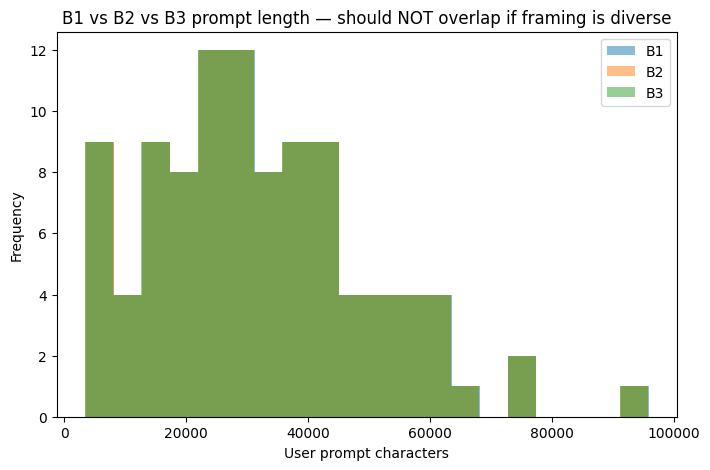

In [54]:
framing_stats = df.groupby("example_id")["user_chars"].agg(["mean", "median", "min", "max", "count"])
display(framing_stats.loc[["B1", "B2", "B3"]] if set(["B1","B2","B3"]).issubset(framing_stats.index) else framing_stats)

def has_code(text):
    return ("```" in text) or ("def " in text) or ("class " in text)

for ex_id in ["B1", "B2", "B3"]:
    subset = df[df["example_id"] == ex_id]
    if len(subset) == 0:
        continue
    code_frac = subset["user_prompt"].apply(has_code).mean()
    print(f"{ex_id}: {code_frac*100:.1f}% of examples contain raw code in the user prompt")

fig, ax = plt.subplots(figsize=(8, 5))
for ex_id in ["B1", "B2", "B3"]:
    subset = df[df["example_id"] == ex_id]
    if len(subset) == 0:
        continue
    ax.hist(subset["user_chars"], bins=20, alpha=0.5, label=ex_id)
ax.set_xlabel("User prompt characters")
ax.set_ylabel("Frequency")
ax.set_title("B1 vs B2 vs B3 prompt length — should NOT overlap if framing is diverse")
ax.legend()
plt.show()